# Quick Smoke Test

Verifies that the notebook execution pipeline works.

In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from beta_spectrum import BetaSpectrum, SpectrumConfig

In [2]:
# Build a basic 99Tc spectrum
config = SpectrumConfig(
    Z_parent=43, Z_daughter=44, A_number=99,
    endpoint_MeV=0.294, transition_type='F2',
    use_screening=False, use_exchange=False,
    use_finite_size=False,
)

In [3]:
spectrum = BetaSpectrum.from_config(config)
W, kinetic_MeV = spectrum.get_energy_grid(config)
flux = spectrum(W)
assert len(W) == len(kinetic_MeV) == len(flux)
assert np.all(np.isfinite(flux))
print(f'Spectrum: {len(W)} points, peak at T={kinetic_MeV[np.argmax(flux)]:.3f} MeV')

Spectrum: 293 points, peak at T=0.072 MeV


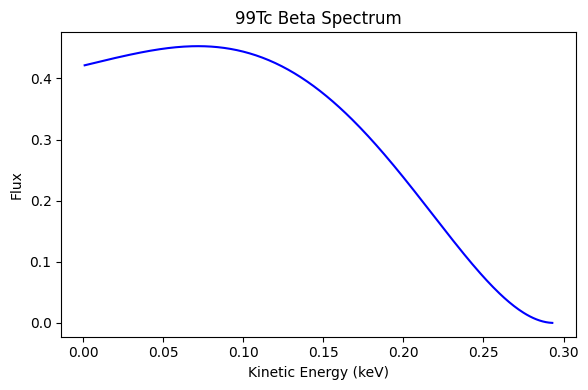

/tmp/ipykernel_6375/2727487349.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
import os
os.makedirs('_plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kinetic_MeV, flux, 'b-')
ax.set_xlabel('Kinetic Energy (keV)')
ax.set_ylabel('Flux')
ax.set_title('99Tc Beta Spectrum')
plt.tight_layout()

plot_path = '_plots/smoke_test_plot.png'
fig.savefig(plot_path, dpi=100, bbox_inches='tight')
display(Image(filename=plot_path))
plt.show()